<a href="https://colab.research.google.com/github/Chaitanya15-ai/ALFIDO/blob/main/ALFIDO_TASK_1(Zomato_data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION
Dataset Shape: (56252, 13)

Columns:
['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']

First 5 Rows:
                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate votes                             phone  \
0          Yes        Yes  4.1/5   775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5   787                      080 41714161   
2          Yes         No  3.8/5   918          

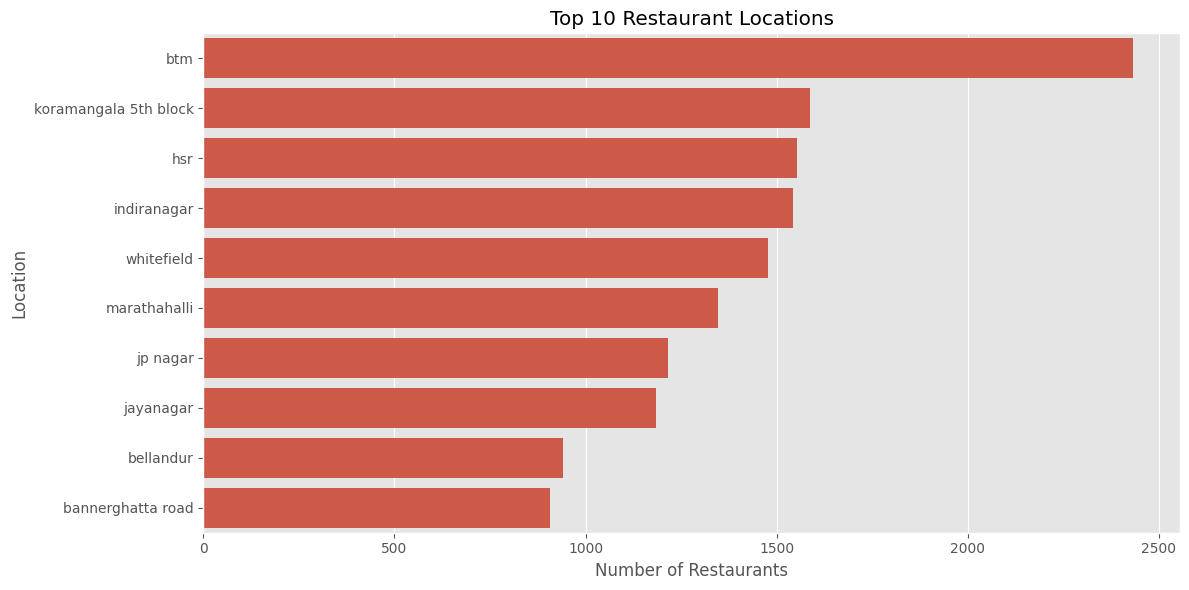

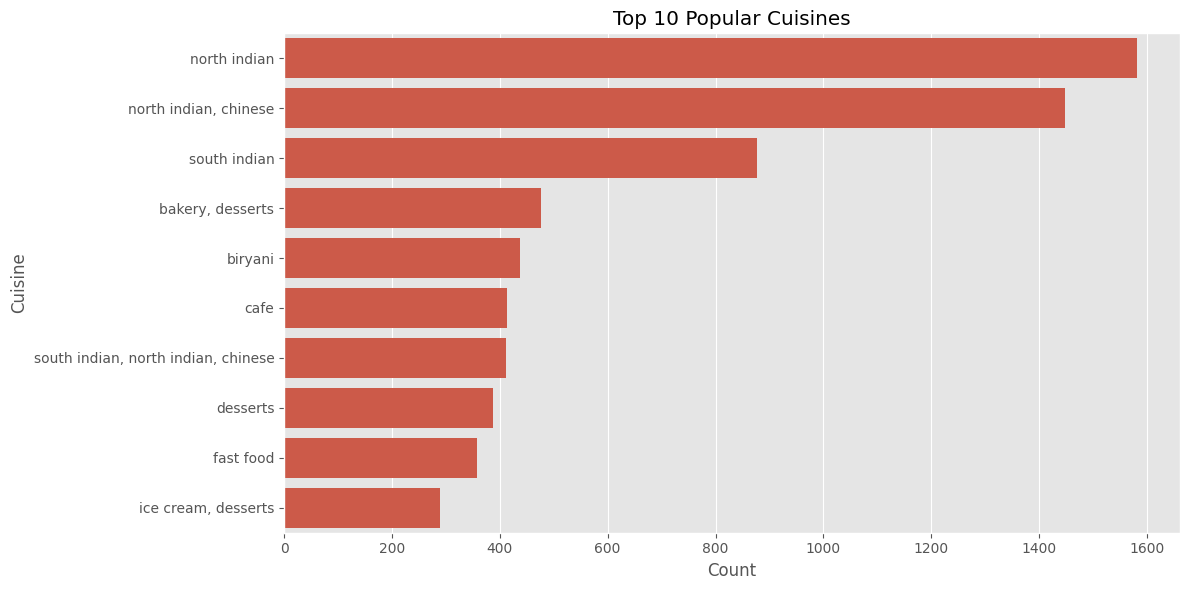

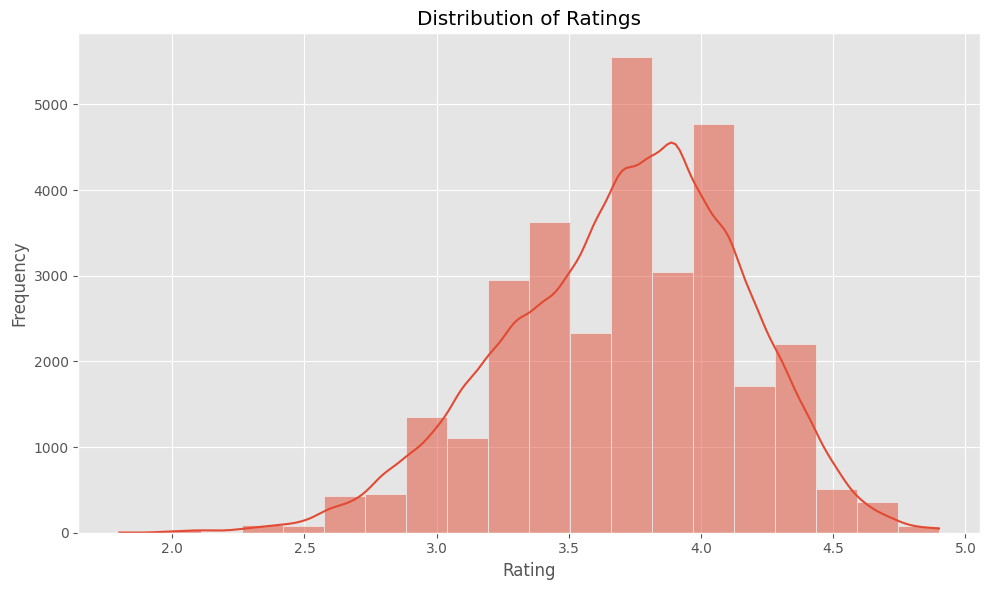

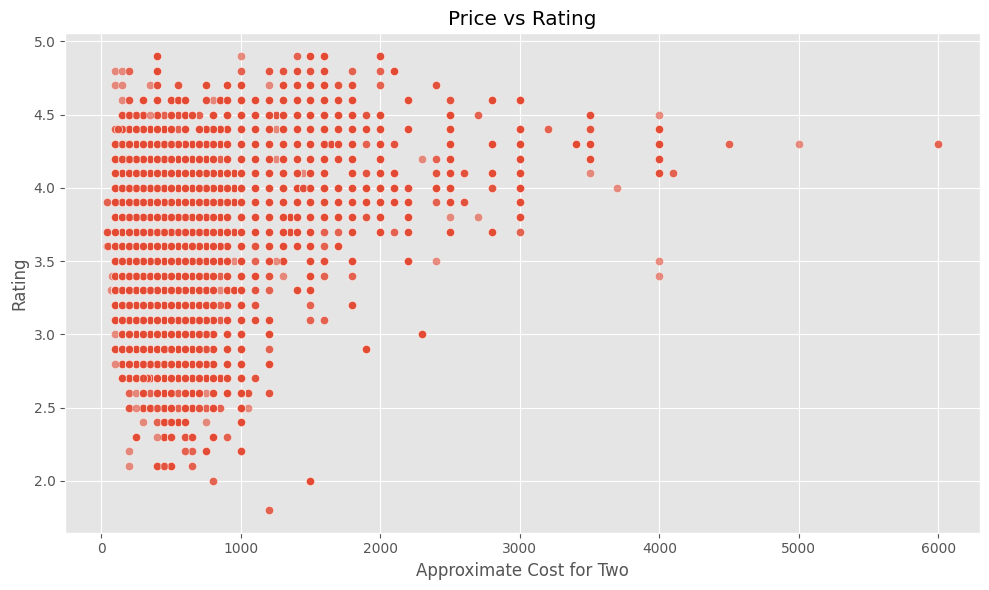

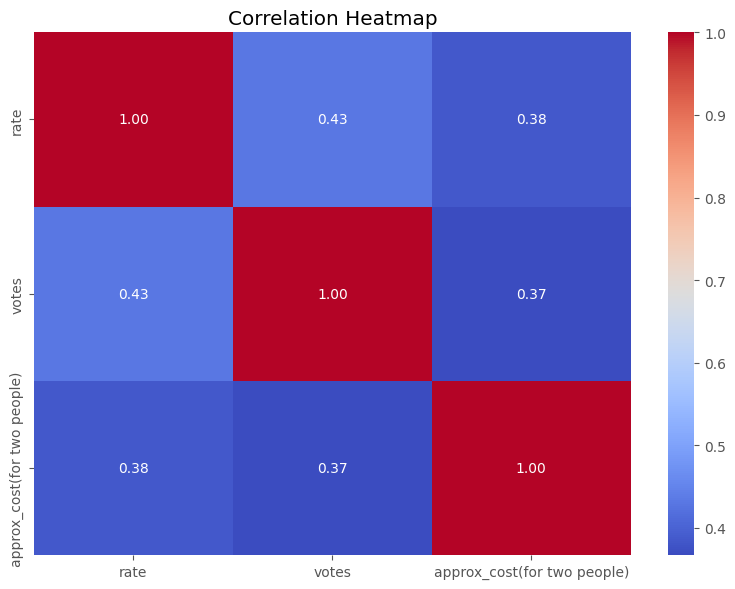

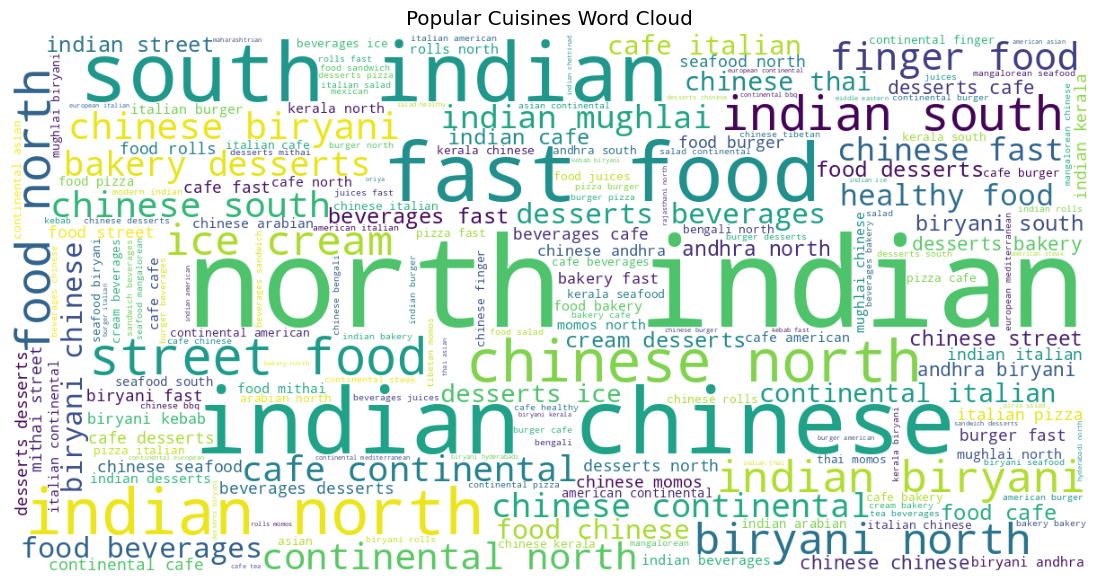


TOP RATED CUISINES
cuisines
continental, north indian, italian, south indian, finger food            4.900000
healthy food, salad, mediterranean                                       4.900000
asian, chinese, thai, momos                                              4.900000
asian, mediterranean, north indian, bbq                                  4.800000
north indian, european, mediterranean, bbq                               4.800000
continental, north indian, chinese, european, bbq, finger food, asian    4.800000
european, mediterranean, north indian, bbq                               4.764286
american, tex-mex, burger, bbq, mexican                                  4.733333
chinese, american, continental, italian, north indian                    4.700000
sushi, japanese, chinese, thai                                           4.700000
Name: rate, dtype: float64


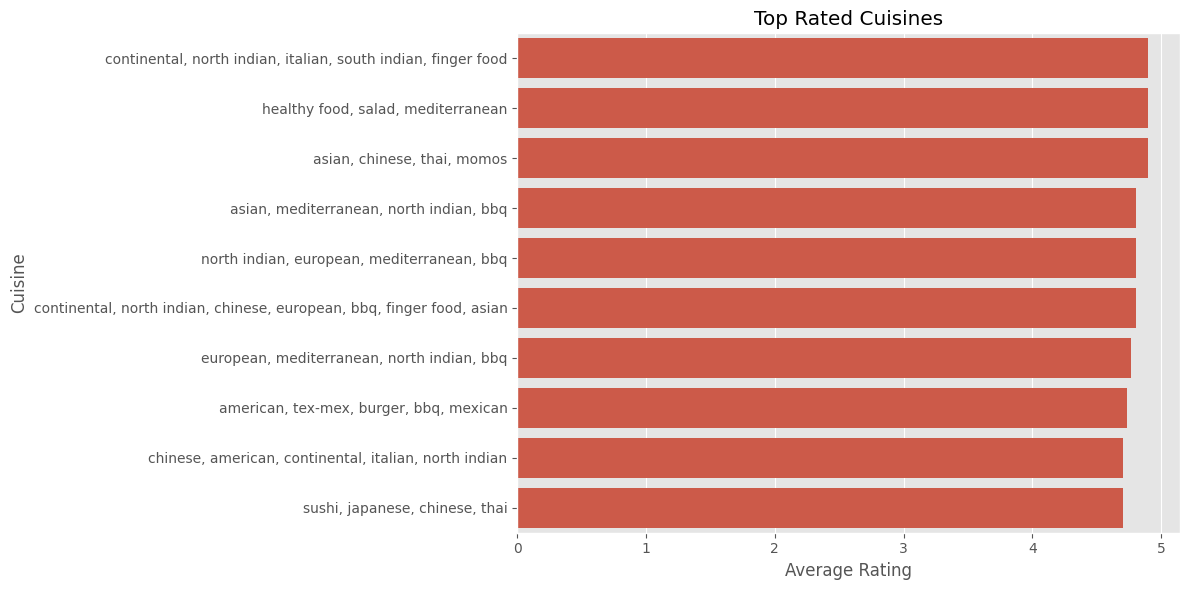


TOP RATED LOCATIONS
location
lavelle road             4.170201
st. marks road           4.054260
koramangala 3rd block    4.051613
koramangala 5th block    4.040265
church street            4.021337
sankey road              4.005000
koramangala 4th block    3.946127
cunningham road          3.944043
mg road                  3.929688
residency road           3.923457
Name: rate, dtype: float64


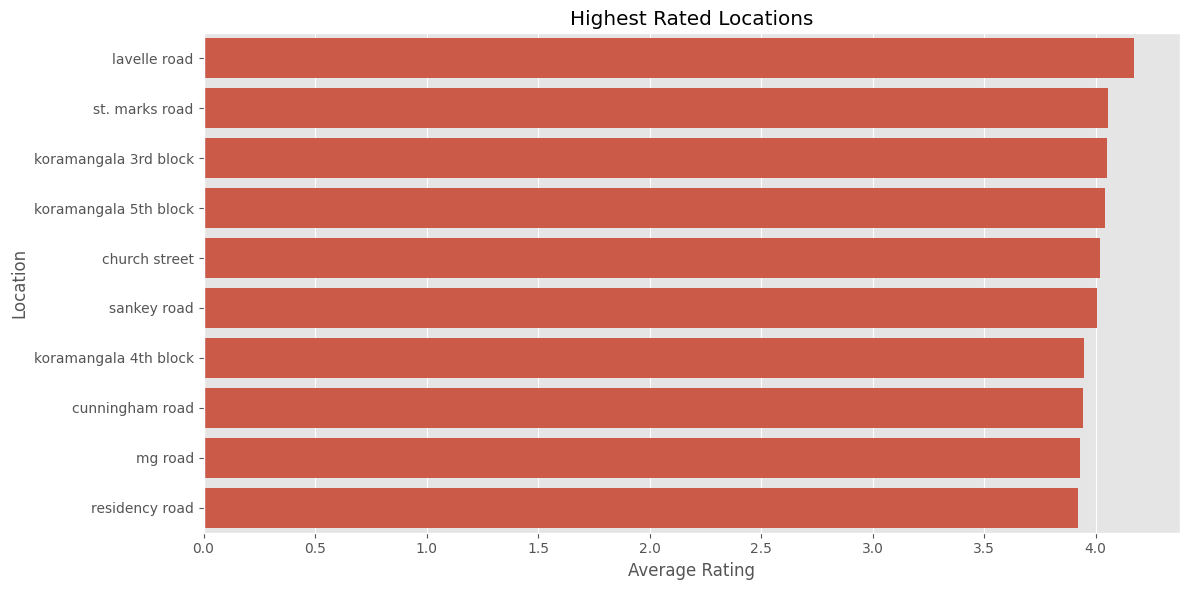

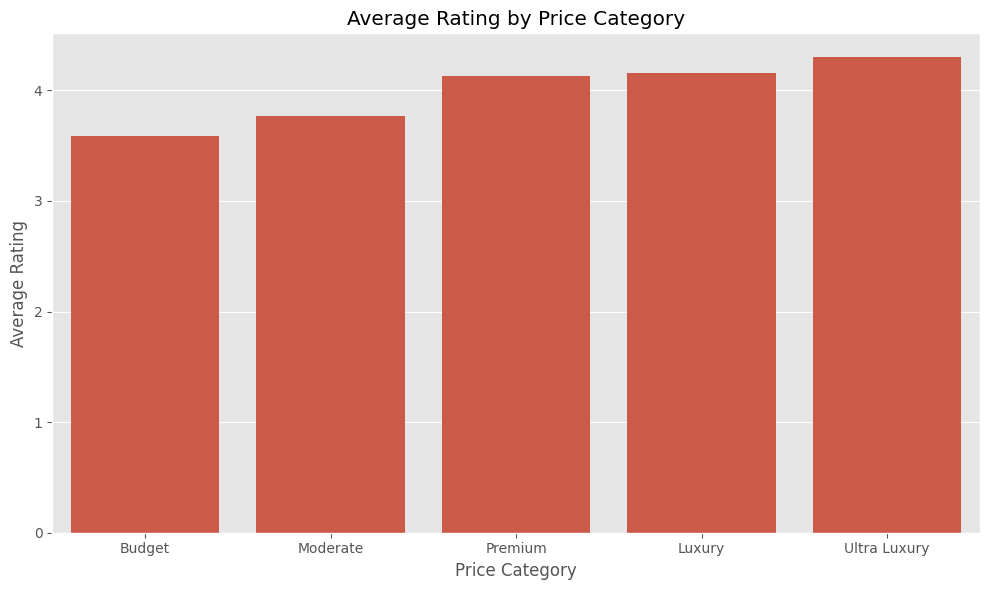


KEY FINDINGS

Top 5 Restaurant Locations:
location
btm                      2434
koramangala 5th block    1587
hsr                      1553
indiranagar              1544
whitefield               1478
Name: count, dtype: int64

Top 5 Popular Cuisines:
cuisines
north indian             1582
north indian, chinese    1448
south indian              877
bakery, desserts          477
biryani                   437
Name: count, dtype: int64

Top 5 Highest Rated Cuisines:
cuisines
continental, north indian, italian, south indian, finger food    4.9
healthy food, salad, mediterranean                               4.9
asian, chinese, thai, momos                                      4.9
asian, mediterranean, north indian, bbq                          4.8
north indian, european, mediterranean, bbq                       4.8
Name: rate, dtype: float64

Top 5 Highest Rated Locations:
location
lavelle road             4.170201
st. marks road           4.054260
koramangala 3rd block    4.051613
koraman

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

csv_path = "/content/zomato.csv"

df = pd.read_csv(csv_path)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

df.drop_duplicates(inplace=True)

categorical_columns = [
    'location',
    'rest_type',
    'cuisines',
    'dish_liked',
    'phone'
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

df['rate'] = df['rate'].astype(str)

df = df[
    (~df['rate'].isin(['NEW', '-', 'nan']))
]

df['rate'] = df['rate'].str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

cost_col = 'approx_cost(for two people)'

df[cost_col] = (
    df[cost_col]
    .astype(str)
    .str.replace(',', '')
)

df[cost_col] = pd.to_numeric(
    df[cost_col],
    errors='coerce'
)

text_columns = [
    'location',
    'rest_type',
    'cuisines'
]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower()

df.dropna(
    subset=['rate', cost_col],
    inplace=True
)

print("\nCleaned Dataset Shape:", df.shape)

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(df.describe())

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title('Top 10 Restaurant Locations')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title('Top 10 Popular Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(
    df['rate'],
    bins=20,
    kde=True
)

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x=cost_col,
    y='rate',
    alpha=0.6
)

plt.title('Price vs Rating')
plt.xlabel('Approximate Cost for Two')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

numeric_columns = [
    'rate',
    'votes',
    cost_col
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

cuisine_text = " ".join(
    df['cuisines'].dropna().astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(cuisine_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Popular Cuisines Word Cloud')
plt.show()

if 'reviews_list' in df.columns:

    review_text = " ".join(
        df['reviews_list']
        .dropna()
        .astype(str)
        .head(5000)
    )

    review_wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white'
    ).generate(review_text)

    plt.figure(figsize=(15, 7))
    plt.imshow(review_wordcloud)
    plt.axis('off')
    plt.title('Review Word Cloud')
    plt.show()

cuisine_rating = (
    df.groupby('cuisines')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\n" + "=" * 60)
print("TOP RATED CUISINES")
print("=" * 60)

print(cuisine_rating)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=cuisine_rating.values,
    y=cuisine_rating.index
)

plt.title('Top Rated Cuisines')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

location_rating = (
    df.groupby('location')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\n" + "=" * 60)
print("TOP RATED LOCATIONS")
print("=" * 60)

print(location_rating)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=location_rating.values,
    y=location_rating.index
)

plt.title('Highest Rated Locations')
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

df['price_category'] = pd.cut(
    df[cost_col],
    bins=[0, 500, 1000, 2000, 5000, 10000],
    labels=[
        'Budget',
        'Moderate',
        'Premium',
        'Luxury',
        'Ultra Luxury'
    ]
)

price_rating = (
    df.groupby('price_category')['rate']
    .mean()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=price_rating.index,
    y=price_rating.values
)

plt.title('Average Rating by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)

print("\nTop 5 Restaurant Locations:")
print(df['location'].value_counts().head(5))

print("\nTop 5 Popular Cuisines:")
print(df['cuisines'].value_counts().head(5))

print("\nTop 5 Highest Rated Cuisines:")
print(cuisine_rating.head(5))

print("\nTop 5 Highest Rated Locations:")
print(location_rating.head(5))

print("\nCorrelation Analysis:")
print(df[numeric_columns].corr())

output_file = "cleaned_zomato_data.csv"

df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)
print(f"Cleaned dataset saved as: {output_file}")